In [1]:
import time
import numpy as np
import qcodes as qc
from qcodes import Station
from qcodes.utils.dataset.doNd import do1d, do2d
from qcodes.dataset.plotting import plot_dataset
from macros import *


# instrument setup - station

In [2]:
station = qc.Station(config_file = 'SET_Station_config.yaml', use_monitor='True')

In [3]:
from zhinst.qcodes import ZISession
mfli_addr = "192.168.0.220"
DEVICE_ID = "dev30577"
session = ZISession(mfli_addr)
device = session.connect_device(DEVICE_ID)
station.add_component(device,name='lockin')

'lockin'

In [4]:
lockin = station.lockin
dac = station.load_instrument('qdac')

Connected to: QDevil QDAC-II (serial:200, firmware:11-1.21) in 0.18s


# data handler - database file

In [5]:
qc.config.core.db_location = "./data/20250725_lockin_dc_ac.db"
qc.initialise_or_create_database_at(qc.config.core.db_location)

In [6]:
exp = qc.load_or_create_experiment(experiment_name="noise_experiment",
                                sample_name = "10Mohm")

# set up experiment parameters 

In [7]:
from qcodes.instrument.parameter import ManualParameter

count = ManualParameter(name='count', label='Index', unit='', initial_value=-1)

def get_lockin_x():
    return lockin.demods[0].sample()['x']

def get_lockin_theta():
    return np.arctan2(lockin.demods[0].sample()['y'], lockin.demods[0].sample()['x'])*180/np.pi
    
lockin_x = qc.Parameter(name='X',label='R',unit='V',get_cmd=get_lockin_x)
lockin_theta = qc.Parameter(name='Theta',label='Theta',unit='deg',get_cmd=get_lockin_theta)

In [8]:
vdc = 0.5
volt_start = -0.001
volt_stop = 0.001
steps = 100
interval_time = 0.03 # 3 times the time constant
basic_mfli_setup(lockin, V_exc=volt_start, Voffset=vdc, frequency=1e3)

do1d(
    lockin.sigouts[0].amplitudes[1].value, 
    volt_start, volt_stop, steps, interval_time,
    lockin_x, lockin_theta,
    measurement_name=f'Voffset={vdc}')


Starting experimental run with id: 13. Using 'qcodes.dataset.do1d'


(Voffset=0.5 #13@/Users/4hsiang/Desktop/Jack/python_project/SET/data/20250725_lockin_dc_ac.db
 --------------------------------------------------------------------------------------------
 zi_baseinstrument_dev30577_sigouts0_amplitudes1_value - numeric
 X - numeric
 Theta - numeric,
 (None,),
 (None,))

In [9]:
v_dc = 0.5
V_ac = 0.02
interval_time = 0.03 # 3 times the time constant
basic_mfli_setup(lockin, V_exc=V_ac, Voffset=v_dc, frequency=1e3)

do1d(count, 
    0, 1000, 1000, interval_time,
    lockin_x, lockin_theta,
    measurement_name=f'Voffset={v_dc} V_exc={V_ac}',)

Starting experimental run with id: 14. Using 'qcodes.dataset.do1d'


(Voffset=0.5 V_exc=0.02 #14@/Users/4hsiang/Desktop/Jack/python_project/SET/data/20250725_lockin_dc_ac.db
 -------------------------------------------------------------------------------------------------------
 count - numeric
 X - numeric
 Theta - numeric,
 (None,),
 (None,))

Starting experimental run with id: 16. Using 'qcodes.dataset.do2d'


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

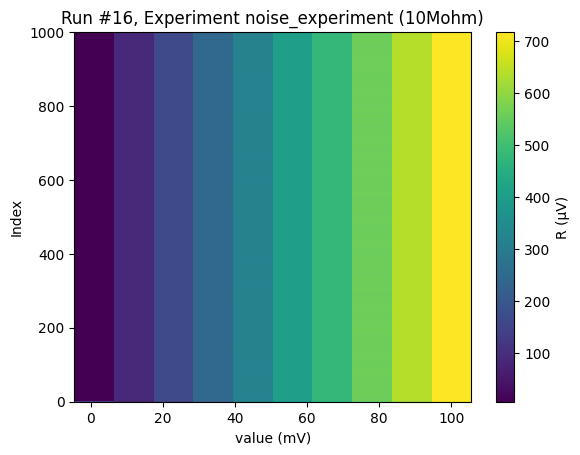

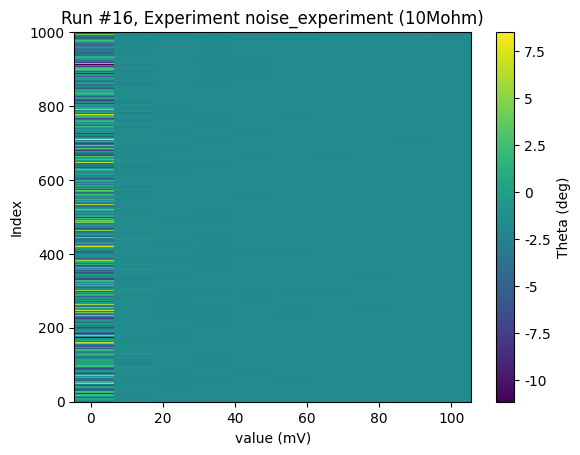

In [16]:
ds, axes,cbs = do2d(
    lockin.sigouts[0].amplitudes[1].value, 0.001, 0.1, 10,interval_time,
    count, 0, 1000, 1000, interval_time,
    lockin_x, lockin_theta,
    measurement_name=f'noise_sweep',
    do_plot=True,
    show_progress=True,
    )

In [13]:
dir(ds)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_metadata_to_netcdf_if_nc_exported',
 '_cache',
 '_completed',
 '_debug',
 '_enqueue_results',
 '_ensure_dataset_written',
 '_estimate_ds_size',
 '_export_as_csv',
 '_export_as_netcdf',
 '_export_data',
 '_export_file_name',
 '_export_info',
 '_finalize_res_dict_array',
 '_finalize_res_dict_numeric_text_or_complex',
 '_finalize_res_dict_standalones',
 '_flush_data_to_database',
 '_get_run_description_from_db',
 '_in_memory_cache',
 '_is_protocol',
 '_is_runtime_protocol',
 '_metadata',
 '_param

In [17]:
ds.to_pandas_dataframe().to_csv('noise_sweep.csv')